In [1]:
import os
import json
import csv
import torch
import torchvision
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import fasterrcnn_resnet50_fpn

class TextDetectionDataset(Dataset):
    def __init__(self, csv_file, images_dir, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms
        self.data = []
        
        with open(csv_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                # region_shape_attributes is a JSON with x, y, width, height
                shape_attrs = json.loads(row["region_shape_attributes"])
                # region_attributes might hold the actual text, but for detection we just need bounding boxes
                text_label = json.loads(row["region_attributes"]).get("text", "")
                
                filename = row["filename"]
                x = shape_attrs["x"]
                y = shape_attrs["y"]
                w = shape_attrs["width"]
                h = shape_attrs["height"]
                
                self.data.append({
                    "filename": filename,
                    "bbox": [x, y, x + w, y + h],
                    "text": text_label
                })
        
        # We might want to group bounding boxes by image. Let's do that:
        self.image_data = {}
        for item in self.data:
            fname = item["filename"]
            if fname not in self.image_data:
                self.image_data[fname] = {
                    "filename": fname,
                    "boxes": [],
                    "labels": []
                }
            self.image_data[fname]["boxes"].append(item["bbox"])
            # For detection alone, we can treat "text" as a single class = 1
            # If you want to classify each distinct text as a separate label, that becomes a classification problem
            self.image_data[fname]["labels"].append(1)
        
        self.image_keys = list(self.image_data.keys())

    def __len__(self):
        return len(self.image_keys)
    
    def __getitem__(self, idx):
        fname = self.image_keys[idx]
        img_path = os.path.join(self.images_dir, fname)
        img = Image.open(img_path).convert("RGB")
        
        boxes = torch.tensor(self.image_data[fname]["boxes"], dtype=torch.float32)
        labels = torch.tensor(self.image_data[fname]["labels"], dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target


In [2]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import cv2
import numpy as np

def predict_and_visualize(model, image_path, device, threshold=0.5):
    """
    Runs object detection on an image and visualizes detected text regions.
    
    Args:
        model: Trained Faster R-CNN model
        image_path: Path to the image file
        device: 'cuda' or 'cpu'
        threshold: Confidence threshold for displaying bounding boxes
    """
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_image = image.copy()
    
    # Transform image to tensor
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Set model to evaluation mode
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    # Extract boxes and scores
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    # Draw bounding boxes on the image
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    # Show image
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.axis("off")
    plt.show()

In [17]:
def train_model(model, train_loader, optimizer, scaler, device, epochs):

    # List to store losses for each epoch
    train_losses = []
    
    for epoch in range(epochs):
        model.train()  
        epoch_loss = 0
        for imgs, targets in train_loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
            with torch.cuda.amp.autocast():  # Mixed Precision
                loss_dict = model(imgs, targets)
                losses = sum(loss for loss in loss_dict.values())
    
            optimizer.zero_grad()
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
    
            epoch_loss += losses.item()
    
        avg_epoch_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_epoch_loss)

        print(f"Epoch {epoch+1} | Train loss: {avg_epoch_loss}")

    return train_losses


---

In [10]:
# Create the dataset
dataset = TextDetectionDataset(csv_file='/kaggle/input/full-annotation-data/via_project_6Sep2024_20h21m_csv (1).csv',
                                     images_dir='/kaggle/input/complete-resized-journal-scans/resized_journal_scans',
                                     transforms=torchvision.transforms.ToTensor())

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: list(zip(*x)))

In [26]:
import torch
import torchvision
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # Speed up convolutions

# Load pre-trained Faster R-CNN and modify it for 2 classes (background, text)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2  # Background + Text
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

model.to(device)  # Move model to GPU

optimizer = optim.Adam(model.parameters(), lr=0.0001)
scaler = torch.cuda.amp.GradScaler()  # Enable mixed precision

<ipython-input-26-f190cd8a01d1>:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Enable mixed precision


In [27]:
train_losses = train_model(model, train_loader, optimizer, scaler, device, epochs=5)

<ipython-input-17-6c98b27434de>:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # Mixed Precision


Epoch 1 | Train loss: 1.7194235801696778
Epoch 2 | Train loss: 0.9979203104972839
Epoch 3 | Train loss: 0.9690192619959513
Epoch 4 | Train loss: 0.9174207031726838
Epoch 5 | Train loss: 0.8839391350746155


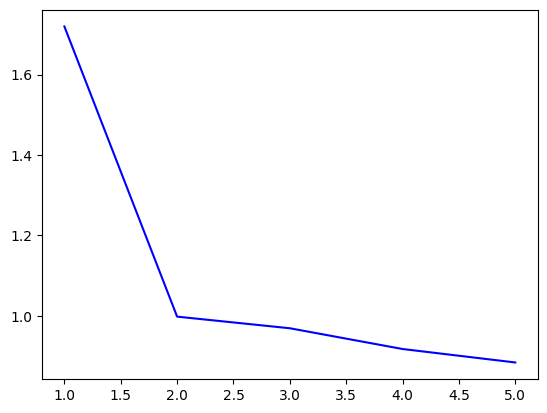

In [28]:
plt.plot(range(1,len(train_losses)+1),train_losses, 'b', label='Training Loss')

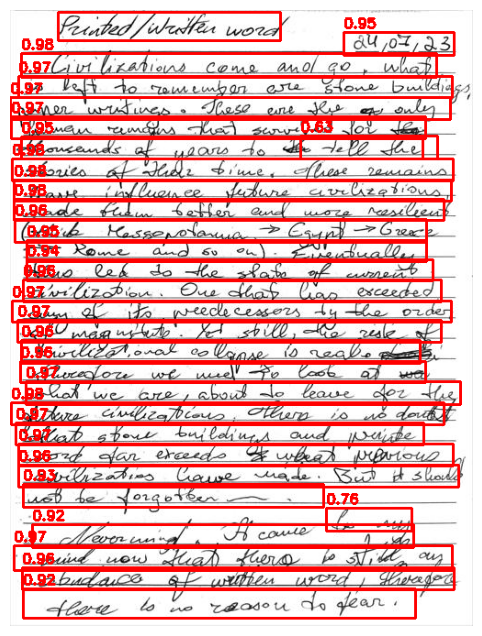

In [34]:
predict_and_visualize(model, "/kaggle/input/complete-resized-journal-scans/resized_journal_scans/IMG_6241.JPG", device="cuda")